The problem is that analysing multiple water-quality measurements manually can make it difficult to quickly determine the pollution level of water. This project aims to use machine learning classification models to analyse water-quality data and predict pollution levels, helping to identify which model provides the most reliable predictions.

Importing Pandas to be able to read the cvs file
Importing matplotlib to plot graphs
Importing seaborn to assist matplotlib to make it look neater

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Water_Quality_Dataset.csv')
print(df.shape)

(1000, 11)


df head prints out the first 5 rows of the data

In [44]:
df.head()

,Timestamp,Location,pH,Turbidity (NTU),Temperature (°C),DO (mg/L),BOD (mg/L),Lead (mg/L),Mercury (mg/L),Arsenic (mg/L),Pollution_Level
0,2024-01-01 00:00:00,L4,8.762414,14.468306,16.461631,6.258335,2.478582,0.002801,0.001924,0.018769,2
1,2024-01-01 01:00:00,L5,7.477966,1.905645,27.446865,2.826120,8.048453,0.019551,0.000633,0.003708,2
2,2024-01-01 02:00:00,L3,7.938278,1.889506,34.623557,3.380191,2.102481,0.019291,0.000205,0.005055,2
3,2024-01-01 03:00:00,L5,8.728748,0.736115,18.802153,6.543794,6.714160,0.003358,0.001058,0.005638,2
4,2024-01-01 04:00:00,L5,7.975335,19.151777,30.851902,4.370861,2.114614,0.006059,0.000124,0.001237,2


Shows us the data structure

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Timestamp         1000 non-null   str    
 1   Location          1000 non-null   str    
 2   pH                1000 non-null   float64
 3   Turbidity (NTU)   1000 non-null   float64
 4   Temperature (°C)  1000 non-null   float64
 5   DO (mg/L)         1000 non-null   float64
 6   BOD (mg/L)        1000 non-null   float64
 7   Lead (mg/L)       1000 non-null   float64
 8   Mercury (mg/L)    1000 non-null   float64
 9   Arsenic (mg/L)    1000 non-null   float64
 10  Pollution_Level   1000 non-null   int64  
dtypes: float64(8), int64(1), str(2)
memory usage: 106.6 KB


Calculating and giving us the summary of the numerical values

In [46]:
df.describe()

,pH,Turbidity (NTU),Temperature (°C),DO (mg/L),BOD (mg/L),Lead (mg/L),Mercury (mg/L),Arsenic (mg/L),Pollution_Level
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,7.250855,10.218681,24.966871,5.928647,5.482985,0.009965,0.000981,0.009855,1.909000
std,1.024515,5.631584,5.756625,2.287483,2.604094,0.005746,0.000569,0.005544,0.307919
min,5.516212,0.502627,15.000233,2.000246,1.008491,0.000128,0.000010,0.000505,0.000000
25%,6.324944,5.566377,19.950098,3.984953,3.242944,0.005000,0.000489,0.005015,2.000000
50%,7.265239,10.236904,25.041492,5.871292,5.368891,0.009894,0.000977,0.009392,2.000000
75%,8.107655,15.148932,29.967260,7.841829,7.730134,0.015130,0.001444,0.014484,2.000000
max,8.997948,19.967776,34.991154,9.981995,9.994153,0.019989,0.001998,0.019922,2.000000


Checking for nun-null values

In [47]:
df.isnull().sum()

Timestamp           0
Location            0
pH                  0
Turbidity (NTU)     0
Temperature (°C)    0
DO (mg/L)           0
BOD (mg/L)          0
Lead (mg/L)         0
Mercury (mg/L)      0
Arsenic (mg/L)      0
Pollution_Level     0
dtype: int64

Checking for duplicates

In [48]:
print(df.duplicated().sum())

0


Checks how many times a value appears ina column

Observations:
We see that the count for the different locations are rather similar so its not like one location is being neglected

In [49]:
df["Location"].value_counts()

Location
L1    210
L4    206
L5    204
L3    190
L2    190
Name: count, dtype: int64

Checks how many records exist for each location in abar graph form

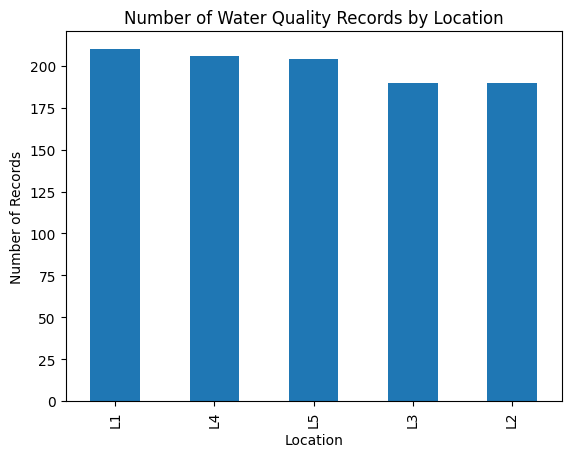

In [50]:
df["Location"].value_counts().plot(kind="bar")

plt.title("Number of Water Quality Records by Location")
plt.xlabel("Location")
plt.ylabel("Number of Records")
plt.show()

The occurance of each unique value in the form of a bar graph

Observations:
Here we can see that Polution level in level 2 (Polutted) is heavily dominating in count

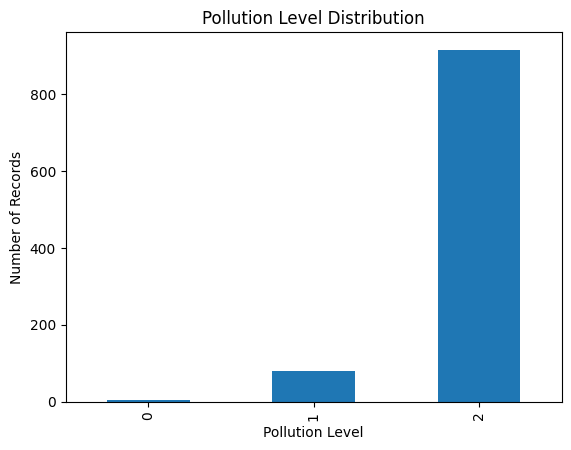

In [51]:
df["Pollution_Level"].value_counts().sort_index().plot(kind="bar")

plt.title("Pollution Level Distribution")
plt.xlabel("Pollution Level")
plt.ylabel("Number of Records")
plt.show()

How many times each unique value occured.

In [52]:
df["Pollution_Level"].value_counts().sort_index()

Pollution_Level
0      6
1     79
2    915
Name: count, dtype: int64

The numner of outliers in each column

Observation:
Notice that the only outliers are on Pollution levels, which we have realized that it doesn't matter because we know that the values in pollution level tells us how the water is

In [53]:
for column in df.select_dtypes(include="number").columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]

    print(column)
    print("Number of outliers:", len(outliers))
    print("Lower limit:", lower_limit)
    print("Upper limit:", upper_limit)
    print()

pH
Number of outliers: 0
Lower limit: 3.6508789314591805
Upper limit: 10.781719881989337

Turbidity (NTU)
Number of outliers: 0
Lower limit: -8.807457454359891
Upper limit: 29.522766462359478

Temperature (°C)
Number of outliers: 0
Lower limit: 4.9243560031834015
Upper limit: 44.99300168347757

DO (mg/L)
Number of outliers: 0
Lower limit: -1.800360576513901
Upper limit: 13.62714224287256

BOD (mg/L)
Number of outliers: 0
Lower limit: -3.4878398217498336
Upper limit: 14.460918120806749

Lead (mg/L)
Number of outliers: 0
Lower limit: -0.010195778681831613
Upper limit: 0.030325484631129086

Mercury (mg/L)
Number of outliers: 0
Lower limit: -0.0009439001526488249
Upper limit: 0.0028762018909619744

Arsenic (mg/L)
Number of outliers: 0
Lower limit: -0.009189087404067162
Upper limit: 0.028687748938651336

Pollution_Level
Number of outliers: 85
Lower limit: 2.0
Upper limit: 2.0



This creates a set of boxplots, one for each listed column, so you can compare their distributions.

Observation:There was no serious observation that caused us to change something 

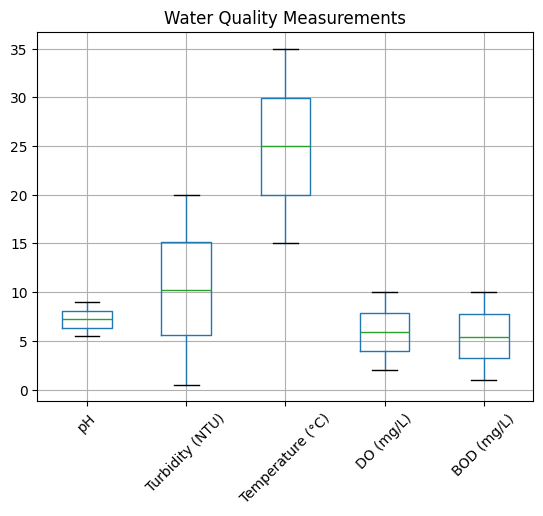

In [54]:
df.boxplot(
    column=[
        "pH",
        "Turbidity (NTU)",
        "Temperature (°C)",
        "DO (mg/L)",
        "BOD (mg/L)"
    ]
)

plt.xticks(rotation=45)
plt.title("Water Quality Measurements")
plt.show()

Groups the data by location and gives the average for each listed location

Observations: 
We notice that all values are relatively similar in each location so once again, there is no location that is heavily different

In [55]:
df.groupby("Location")[
    ["pH", "Turbidity (NTU)", "Temperature (°C)",
     "DO (mg/L)", "BOD (mg/L)"]
].mean()

,pH,Turbidity (NTU),Temperature (°C),DO (mg/L),BOD (mg/L)
Location,,,,,
L1,7.191603,10.302628,25.507970,5.953713,5.649244
L2,7.311730,10.884517,25.381239,5.908332,5.598476
L3,7.204735,9.133566,24.816292,5.854478,5.258485
L4,7.324825,9.875058,24.287666,5.852014,5.529789
L5,7.223412,10.869760,24.850037,6.068231,5.366100


Checking for the pollution level at each location

In [56]:
pd.crosstab(df["Location"], df["Pollution_Level"])

Pollution_Level,0,1,2
Location,,,
L1,3,11,196
L2,1,15,174
L3,1,18,171
L4,1,20,185
L5,0,15,189


Plotting a heatmap to see the correlation between all the attributes in the dataset

Observation: Turbidity has the highest correlation for determining the Pollution_Level (Which is our target attribute) so it will be the one that we're leaning towards the most

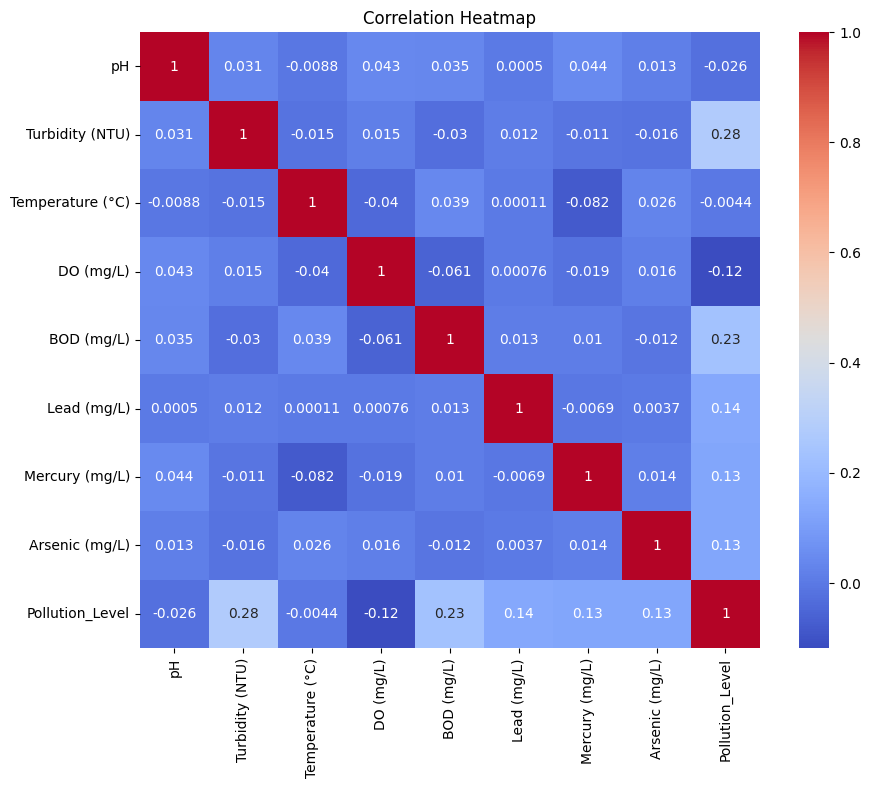

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

The correlation between the pollution level and the attributes

In [58]:
df.select_dtypes(include="number").corr()["Pollution_Level"].sort_values()

DO (mg/L)          -0.118351
pH                 -0.025698
Temperature (°C)   -0.004387
Mercury (mg/L)      0.127162
Arsenic (mg/L)      0.127810
Lead (mg/L)         0.136399
BOD (mg/L)          0.232708
Turbidity (NTU)     0.275996
Pollution_Level     1.000000
Name: Pollution_Level, dtype: float64

Plotting a scatter plot to see the correlation between the pollution level and the turbidity

Observations:
We can see that distinctly that there are clear values where pollution level of 2 is gurranteed and when pollution level of 0 and 1 stops

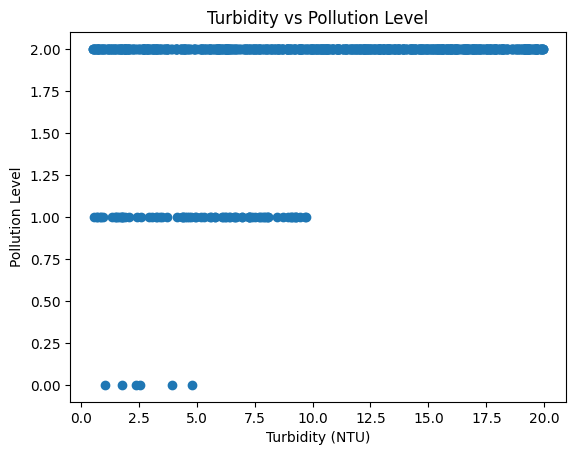

In [59]:
plt.scatter(
    df["Turbidity (NTU)"],
    df["Pollution_Level"]
)

plt.title("Turbidity vs Pollution Level")
plt.xlabel("Turbidity (NTU)")
plt.ylabel("Pollution Level")
plt.show()

Pollution level is the target attribute

In [60]:
y = df["Pollution_Level"]

Pollution is dependent on the following attributes

In [61]:
X = df[
    [
        "pH",
        "Turbidity (NTU)",
        "Temperature (°C)",
        "DO (mg/L)",
        "BOD (mg/L)",
        "Lead (mg/L)",
        "Mercury (mg/L)",
        "Arsenic (mg/L)"
    ]
]

From this point onwards, we are going to be testing some models to see how accurate they are in determining the Pollution level based off the features of X before we start with Forecasting


Testing the decision tree model

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.98
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.88      0.88      0.88        16
           2       0.99      0.99      0.99       183

    accuracy                           0.98       200
   macro avg       0.62      0.62      0.62       200
weighted avg       0.98      0.98      0.98       200



Testing the random forest model

In [63]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_rf.fit(X_train, y_train)

prediction_rf = model_rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, prediction_rf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.98
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.88      0.88      0.88        16
           2       0.99      0.99      0.99       183

    accuracy                           0.98       200
   macro avg       0.62      0.62      0.62       200
weighted avg       0.98      0.98      0.98       200



Logistic regression model to test

In [64]:
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train, y_train)

prediction_lr = model_lr.predict(X_test)

accuracy_lr = accuracy_score(y_test, prediction_lr)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.98
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.88      0.88      0.88        16
           2       0.99      0.99      0.99       183

    accuracy                           0.98       200
   macro avg       0.62      0.62      0.62       200
weighted avg       0.98      0.98      0.98       200



Importing the XGBoost and classification report

In [65]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [67]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)

In [68]:
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

In [69]:
y_pred = model.predict(X_test)

In [70]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.99
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.94      0.94      0.94        16
           2       0.99      1.00      1.00       183

    accuracy                           0.99       200
   macro avg       0.64      0.65      0.64       200
weighted avg       0.99      0.99      0.99       200



C:\Users\Senzwa4\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Senzwa4\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Senzwa4\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

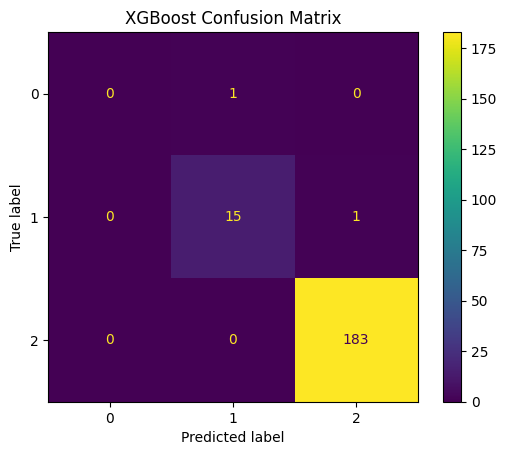

In [71]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

**Forecasting**

Here we converting the date from String to Date Dtype

In [72]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

Here we are sorting the values by ascending order based on location and timestamp.

Then we create lag_cols which is going to store the names of our columns only

In the for loop, I am creating "lag" columns which will hold the previous value of that specific column.

Crucially grouping by location so that we don't accidently take the readings of another column.

In [73]:
df = df.sort_values(["Location", "Timestamp"]).reset_index(drop=True)
lag_cols = [
    "pH", "Turbidity (NTU)", "Temperature (°C)", "DO (mg/L)",
    "BOD (mg/L)", "Lead (mg/L)", "Mercury (mg/L)", "Arsenic (mg/L)",
    "Pollution_Level"
]
for col in lag_cols:
    df[f"{col}_lag1"] = df.groupby("Location")[col].shift(1)
df.head()

,Timestamp,Location,pH,Turbidity (NTU),Temperature (°C),DO (mg/L),BOD (mg/L),Lead (mg/L),Mercury (mg/L),Arsenic (mg/L),Pollution_Level,pH_lag1,Turbidity (NTU)_lag1,Temperature (°C)_lag1,DO (mg/L)_lag1,BOD (mg/L)_lag1,Lead (mg/L)_lag1,Mercury (mg/L)_lag1,Arsenic (mg/L)_lag1,Pollution_Level_lag1
0,2024-01-01 18:00:00,L1,8.544637,2.102348,26.301706,4.022865,7.924983,0.001494,0.000960,0.004983,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-01 23:00:00,L1,6.673190,7.947823,22.140587,5.818803,2.792977,0.009985,0.001422,0.011553,1,8.544637,2.102348,26.301706,4.022865,7.924983,0.001494,0.000960,0.004983,2.0
2,2024-01-02 00:00:00,L1,8.309987,4.510902,33.523881,4.806553,3.557659,0.016875,0.000970,0.007411,2,6.673190,7.947823,22.140587,5.818803,2.792977,0.009985,0.001422,0.011553,1.0
3,2024-01-02 09:00:00,L1,7.082763,6.210030,15.583395,3.769910,5.530106,0.010743,0.000816,0.002354,1,8.309987,4.510902,33.523881,4.806553,3.557659,0.016875,0.000970,0.007411,2.0
4,2024-01-02 14:00:00,L1,7.244287,16.329511,22.956733,5.672992,5.923408,0.015948,0.001809,0.003587,2,7.082763,6.210030,15.583395,3.769910,5.530106,0.010743,0.000816,0.002354,1.0


We are looping through the "lag_cols" array again but this time we stop before "Pollution_Level"

Grouping by location to prevent leaking different locations

Then here we are looked at 3 values of a column at a time then only taking the mean of those values to create our roll3 value

In [81]:

# rolling mean of the last 3 previous readings at the same location
for col in lag_cols[:-1]:
    df[f"{col}_roll3"] = (
        df.groupby("Location")[col]
          .transform(lambda s: s.shift(1).rolling(3).mean())
    )

Creating an hour column and day of the week column which will be used when modeling as a feature

In [83]:
df["hour"] = df["Timestamp"].dt.hour
df["dayofweek"] = df["Timestamp"].dt.dayofweek

Drop any row that has missing roll3 values, because it won't be used for modeling 

Then we getting how much rows we actually dropped 

In [84]:
df_fc = df.dropna().reset_index(drop=True)
print("Rows before dropping first-per-location readings:", len(df))
print("Rows available for forecasting model:", len(df_fc))
df_fc.head()

Rows before dropping first-per-location readings: 1000
Rows available for forecasting model: 985


,Timestamp,Location,pH,Turbidity (NTU),Temperature (°C),DO (mg/L),BOD (mg/L),Lead (mg/L),Mercury (mg/L),Arsenic (mg/L),...,pH_roll3,Turbidity (NTU)_roll3,Temperature (°C)_roll3,DO (mg/L)_roll3,BOD (mg/L)_roll3,Lead (mg/L)_roll3,Mercury (mg/L)_roll3,Arsenic (mg/L)_roll3,hour,dayofweek
0,2024-01-02 09:00:00,L1,7.082763,6.210030,15.583395,3.769910,5.530106,0.010743,0.000816,0.002354,...,7.842605,4.853691,27.322058,4.882740,4.758540,0.009451,0.001117,0.007982,9,1
1,2024-01-02 14:00:00,L1,7.244287,16.329511,22.956733,5.672992,5.923408,0.015948,0.001809,0.003587,...,7.355313,6.222918,23.749288,4.798422,3.960247,0.012534,0.001069,0.007106,14,1
2,2024-01-02 17:00:00,L1,6.768379,7.096216,15.898226,2.949150,4.721649,0.008278,0.001242,0.013991,...,7.545679,9.016814,24.021336,4.749818,5.003724,0.014522,0.001198,0.004450,17,1
3,2024-01-02 21:00:00,L1,7.822381,8.925499,30.085299,2.261272,9.582693,0.002972,0.000342,0.009070,...,7.031810,9.878586,18.146118,4.130684,5.391721,0.011656,0.001289,0.006644,21,1
4,2024-01-03 07:00:00,L1,8.124862,16.410965,19.807978,2.930868,4.434548,0.019199,0.001864,0.014111,...,7.278349,10.783742,22.980086,3.627805,6.742583,0.009066,0.001131,0.008883,7,2


In [85]:
y_fc = df_fc["Pollution_Level"]
X_fc = df_fc.drop(columns=[
    "Timestamp",
    "Location",
    "Pollution_Level",
    "pH",
    "Turbidity (NTU)",
    "Temperature (°C)",
    "DO (mg/L)",
    "BOD (mg/L)",
    "Lead (mg/L)",
    "Mercury (mg/L)",
    "Arsenic (mg/L)"
])

split_idx = int(len(df_fc) * 0.8)
X_train_fc, X_test_fc = X_fc.iloc[:split_idx], X_fc.iloc[split_idx:]
y_train_fc, y_test_fc = y_fc.iloc[:split_idx], y_fc.iloc[split_idx:]

print("Train size:", len(X_train_fc), " Test size:", len(X_test_fc))

Train size: 788  Test size: 197


In [89]:
model_rf_fc = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf_fc.fit(X_train_fc, y_train_fc)

pred_rf_fc = model_rf_fc.predict(X_test_fc)
print(classification_report(y_test_fc, pred_rf_fc))

              precision    recall  f1-score   support

           1       0.00      0.00      0.00        15
           2       0.92      1.00      0.96       182

    accuracy                           0.92       197
   macro avg       0.46      0.50      0.48       197
weighted avg       0.85      0.92      0.89       197



C:\Users\Senzwa4\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Senzwa4\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Senzwa4\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [88]:
model_xgb_fc = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)
model_xgb_fc.fit(X_train_fc, y_train_fc)

pred_xgb_fc = model_xgb_fc.predict(X_test_fc)
print(classification_report(y_test_fc, pred_xgb_fc))

              precision    recall  f1-score   support

           1       0.00      0.00      0.00        15
           2       0.92      0.99      0.96       182

    accuracy                           0.92       197
   macro avg       0.46      0.50      0.48       197
weighted avg       0.85      0.92      0.88       197



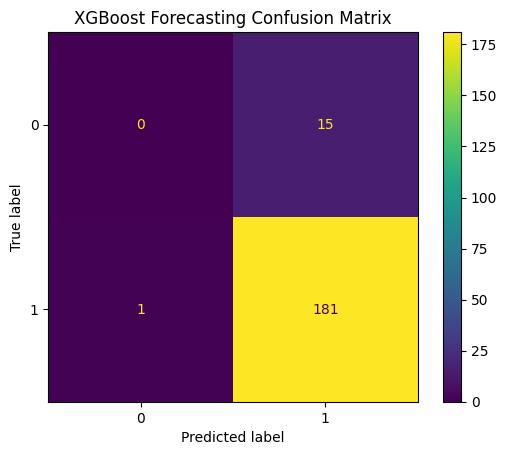

,Model,Accuracy
0,"XGBoost (snapshot, random split)",0.990000
1,Random Forest (forecasting),0.923858
2,XGBoost (forecasting),0.918782


In [90]:
cm_fc = confusion_matrix(y_test_fc, pred_xgb_fc)
disp_fc = ConfusionMatrixDisplay(confusion_matrix=cm_fc)
disp_fc.plot()
plt.title("XGBoost Forecasting Confusion Matrix")
plt.show()

comparison = pd.DataFrame({
    "Model": ["XGBoost (snapshot, random split)", "Random Forest (forecasting)", "XGBoost (forecasting)"],
    "Accuracy": [accuracy_score(y_test, y_pred), accuracy_rf_fc, accuracy_xgb_fc]
})
comparison

From here we save the xgb forecasting model into a joblib and the features that will be needed by the model

In [91]:
import joblib

joblib.dump(model_xgb_fc, "xgb_forecast_model.joblib")

# Save the exact feature order the forecasting model expects
feature_columns_fc = list(X_fc.columns)
joblib.dump(feature_columns_fc, "feature_columns_fc.joblib")

print("Saved forecasting model and feature columns.")

Saved forecasting model and feature columns.


Then here we create the app.py file to that we can use streamlit to run it 

In [80]:
app_code = '''
import os
import streamlit as st
import pandas as pd
import joblib
from datetime import datetime

BASE_DIR = os.path.dirname(os.path.abspath(__file__))
model = joblib.load(os.path.join(BASE_DIR, "xgb_forecast_model.joblib"))
feature_columns = joblib.load(os.path.join(BASE_DIR, "feature_columns_fc.joblib"))

measurement_cols = [
    "pH", "Turbidity (NTU)", "Temperature (°C)", "DO (mg/L)",
    "BOD (mg/L)", "Lead (mg/L)", "Mercury (mg/L)", "Arsenic (mg/L)",
    "Pollution_Level"
]

st.title("Water Pollution Forecast")
st.write(
    "Enter the last 3 readings at this location (oldest first, most recent last), "
    "plus the date/time you\\'re forecasting for."
)

default_rows = pd.DataFrame(
    [[7.0, 5.0, 25.0, 5.0, 3.0, 0.005, 0.001, 0.005, 1]] * 3,
    columns=measurement_cols
)
history_df = st.data_editor(default_rows, num_rows="fixed", key="history")

st.subheader("Timestamp to forecast")
forecast_date = st.date_input("Date")
forecast_time = st.time_input("Time")
forecast_dt = datetime.combine(forecast_date, forecast_time)

if st.button("Predict Pollution Level"):
    lag1_values = history_df.iloc[-1]
    roll3_values = history_df[measurement_cols[:-1]].mean()

    input_row = {}
    for col in measurement_cols:
        input_row[f"{col}_lag1"] = lag1_values[col]
    for col in measurement_cols[:-1]:
        input_row[f"{col}_roll3"] = roll3_values[col]

    input_row["hour"] = forecast_dt.hour
    input_row["dayofweek"] = forecast_dt.weekday()

    input_df = pd.DataFrame([input_row])[feature_columns]

    prediction = model.predict(input_df)[0]
    st.success(f"Predicted Pollution Level: {prediction}")

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(input_df)[0]
        proba_df = pd.DataFrame({"Pollution Level": model.classes_, "Probability": proba})
        st.bar_chart(proba_df.set_index("Pollution Level"))
'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("app.py created.")

app.py created.
